У цьому домашньому завданні ми продовжуємо працювати з набором даних `Yulu`, з яким почали працювати в "hw 4.3. Робота з DataFrame. Діаграма розсіювання.". Фокус цього ДЗ в тому, аби будувати візуалізації використовуючи методи бібліотеки `seaborn`. Це дозволяє будувати гарніні візуалізації, а іноді також робити це швидше, ніж з `matplotlib`.

Документація до тої частини бібліотеки, з якою тут працюємо

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів

0. Імпортуйте бібліотеки `matplotlib.pyplot`, `seaborn` та `pandas`.  Завантажте дані з файла `yulu_rental.csv` у `pandas.DataFrame` `df`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/python_labs/chapter 4/yulu_rental.csv')

print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


1. Користуючись методом `seaborn.jointplot` побудуйте візуалізацію графіка розсіювання між змінними `humidity` та `count`, зазначивши колір точки в відповідності до значення змінної `weather`. Опишіть свої спостереження з графіку. Що бачите цікавого і корисного для прийняття рішень на основі цих даних?

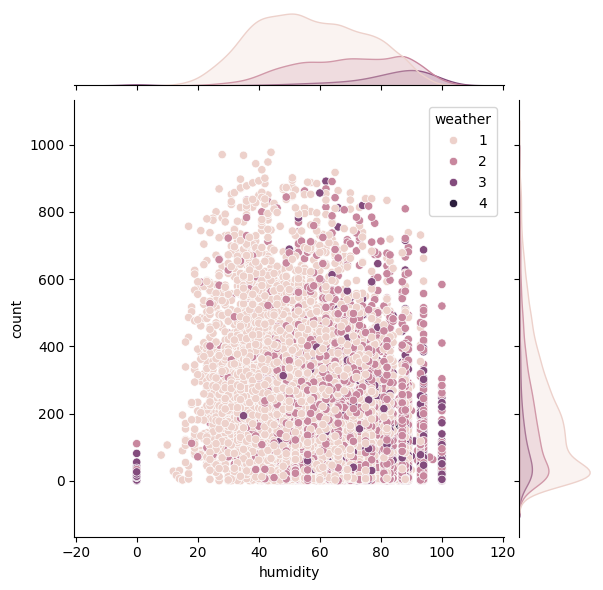

In [4]:
sns.jointplot(x='humidity', y='count', data=df, hue='weather')
plt.show()

З графіку можна зрозуміти, що за ясної погоди навіть коли вологість зростає, кількість орендованих велосипедів є високою. В погану погоду, таку як дощ або сніг, кількість орендованих велосипедів зазвичай менша, що є логічно.

Графік дозволяє компанії визначити періоди, коли погана погода має найбільший вплив на кількість орендованих велосипедів, а це може бути корисним для планування ресурсів або рекламних кампаній.

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=16BksRhZzoz4ynPKCPjXEek56XBsAEF6T)

2. Відфільтруйте і збережіть в окремій змінній лише дані з сезоно "весна" і "літо" (звернітся до опису даних вгорі ноутбуку, аби зрозуміти, які значення вам треба обрати.
Користуючись методом `seaborn.jointplot` побудуйте візуалізацію графіка розсіювання між змінними `casual` та `registered`, зазначивши колір точки в відповідності до значення змінної `season`. Встановіть прозорість на 0.2.

Опишіть свої спостереження з графіку. Що бачите цікавого і корисного для прийняття рішень на основі цих даних?

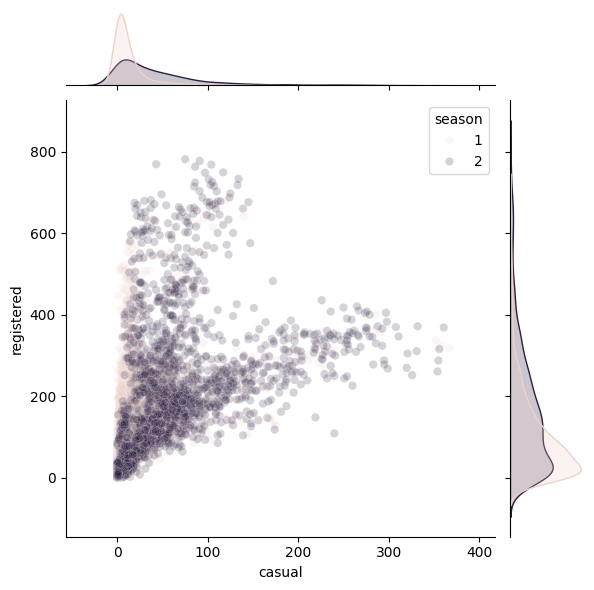

In [5]:
spring_summer_data = df[(df['season'] == 1) | (df['season'] == 2)]

sns.jointplot(x='casual', y='registered', data=spring_summer_data, hue='season', alpha=0.2)
plt.show()


Отже, залежність між кількістю неформальних користувачів і загальною кількістю зареєстрованих користувачів є зростаючою, проте навесні більш стрімко, ніж влітку (можливо тому, що влітку взагалі більше людей користується послугами оренди велосипедів, а навесні тільки більш неформальні))

Тому необхідно завжди враховувати особливості різних категорій користувачів, оскільки неформальні користувачі становлять вагому частину з усіх зареєстрованих.




3. Для дослідження як розподілу значень  `humidity` в залежності від погоди (`weather`) побудуйте візуалізацію типу "ящик з вусами" (box plot)користуючись відповідним методом бібліотеки seaborn:

https://seaborn.pydata.org/generated/seaborn.boxplot.html


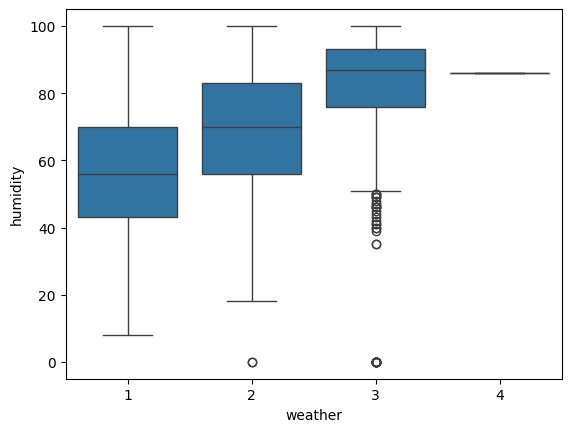

In [6]:
sns.boxplot(x='weather', y='humidity', data=df)
plt.show()


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1_6CBacvDlbuV1XD9GNoGn9sJOSfr74pS)


4. Використайте бібліотеку Seaborn для створення **парних графіків** (pairplot) розсіювання, які показуватимуть взаємозв'язки між кількістю зареєстрованих, неформальних користувачів та загальною кількістю велосипедів, взятих на прокат. Кожен графік повинен розрізняти робочі та святкові дні за кольором.

Для побудови цієї візуалізації спочатку відфільтруйте потрібні колонки в даних і потім зробіть візуалізацію.

Проаналізуйте візуалізацію і скажіть, чи можна виявити особливу поведінку користувачів у святкові дні з цих графіків?

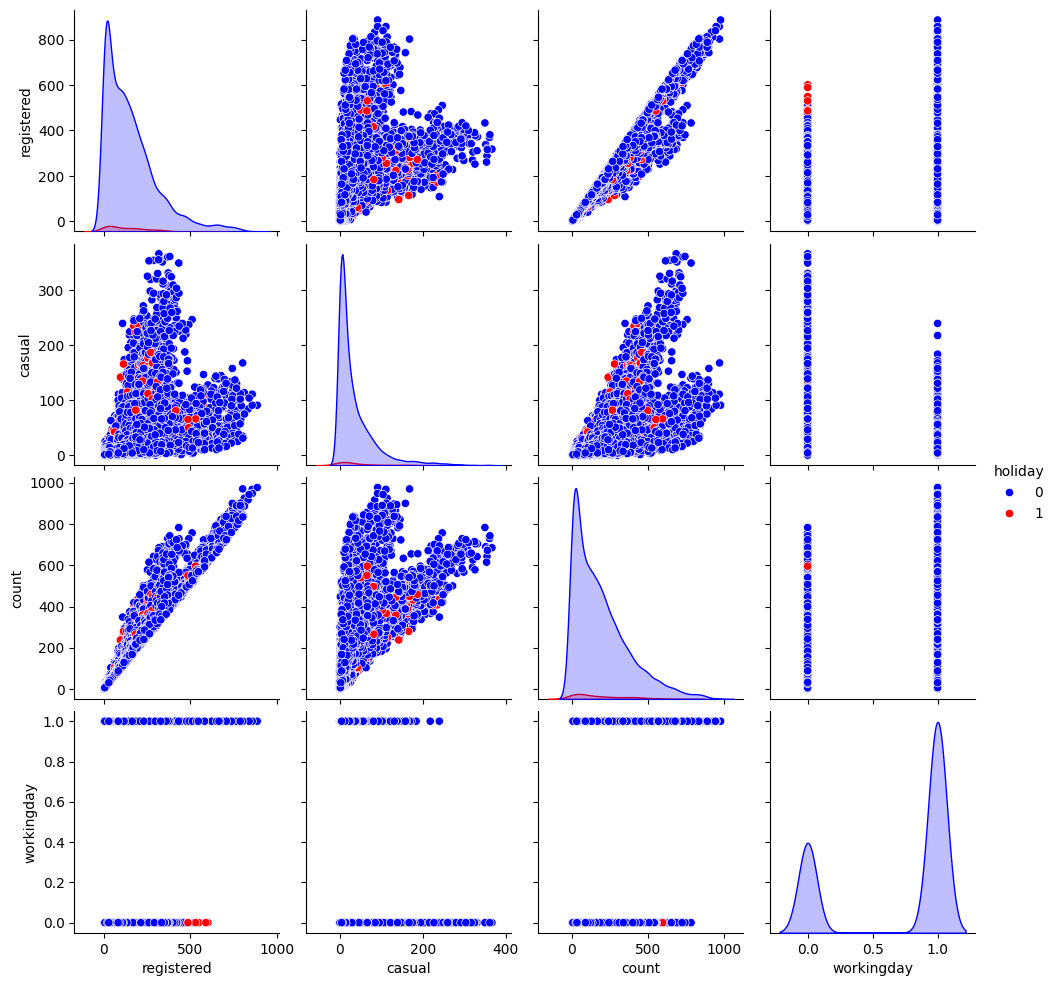

In [9]:
filtered_data = df[['registered', 'casual', 'count', 'workingday', 'holiday']]

sns.pairplot(filtered_data, hue='holiday', palette={0: 'blue', 1: 'red'})
plt.show()


Спостерігається різницюя у поведінці користувачів в робочі та святкові дні.

У робочі дні може відстежуватися регулярність в користуванні велосипедами (наприклад, вранці та ввечері, коли люди їдуть на роботу чи повертаються).

В святкові дні люди мають більше вільного часу, тому  користуються велосипедами в різний час і не так інтенсивно, здебільшого це неформальні користувачі. Компанії слід звернути увагу на залучення клієнтів у вихідні дні, можливо, рекламними роликами та знижками.







5. Змініть тип даних колонки `datetime` на `pandas.datetime`.

In [10]:
df['datetime'] = pd.to_datetime(df.datetime)

 Тепер давайте візуалізуємо кількість зареєстрованих та казуальних користувачів поденно. Для цього виконайте код нижче і після цього створіть нову змінну `df_viz` яка містить лише колонки `'date', 'registered', 'casual'`, згрупуйте дані за датою і відобразіть на **одному** графіку поденну динаміку двох показників з допомогою `pandas.plot`.

In [11]:
df['date'] = df.datetime.dt.date

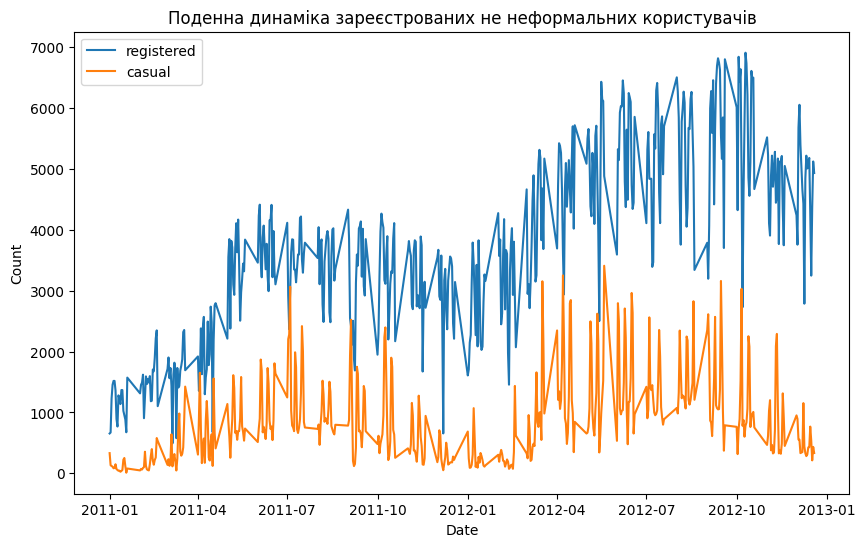

In [14]:
df_viz = df[['date', 'registered', 'casual']]

df_viz = df_viz.groupby('date').sum()

df_viz.plot(figsize=(10, 6))
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Поденна динаміка зареєстрованих не неформальних користувачів')
plt.show()


З графіків зрозуміло, що влітку кількість неформальних користувачів зростає (як і загалом зареєстрованих), оскільки погодні умови сприятливіші для поїздок на велосипедах.

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1XGBqmFLXiI_v-MBEOiCQNyW6sUpvII1n)
